## CNN NAS

In [1]:
import reward_functions
# Some magic so that the notebook will reload the external python script file any time you edit and save the .py file;
%load_ext autoreload
%autoreload 2

([('64', '1', '2'), ('32', '5', '0'), ('256', '5', '1'), ('16', '1', '1'), ('64', '3', '1')], tensor([[-4.3875],
        [-3.9384],
        [-3.5167],
        [-3.6927],
        [-3.5755]], grad_fn=<StackBackward0>))
CNNController(
  (embedding): Embedding(45, 8)
  (rnn): LSTM(8, 32, batch_first=True)
  (fc_filter): Linear(in_features=32, out_features=5, bias=True)
  (fc_kernel): Linear(in_features=32, out_features=3, bias=True)
  (fc_padding): Linear(in_features=32, out_features=3, bias=True)
  (meta_layer): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=False)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=False)
  )
)


In [2]:
import torch
import torch.nn as nn
import time
from torch.utils.data import DataLoader
import os

import utils

import logging
logging.basicConfig(level=logging.INFO, filename=os.path.join(os.getcwd(), 'log.log'), filemode='w')

logger = logging.getLogger(__name__)
logger.setLevel(logging.INFO)




device = utils.get_device_available()
print(torch.__version__)
print(device)

2.4.1
cuda


In [3]:
def is_valid_encoding(encoding):
    if len(encoding) < 3 or encoding[0] != "START" or encoding[-1] != "END":
        return False

    for i in range(1, len(encoding) - 1):
        if not encoding[i].isnumeric():
            return False

    return True


def split_dataset(data, labels, split_ratio=0.8):
    dataset = torch.utils.data.TensorDataset(data, labels)
    train_size = int(split_ratio * len(dataset))
    test_size = len(dataset) - train_size

    train_set, test_set = torch.utils.data.random_split(dataset, [train_size, test_size])

    train_data, train_labels = zip(*train_set)
    train_data = torch.stack(train_data)
    train_labels = torch.stack(train_labels)

    test_data, test_labels = zip(*test_set)
    test_data = torch.stack(test_data)
    test_labels = torch.stack(test_labels)

    return (train_data, train_labels), (test_data, test_labels)

### RL Loop

In [29]:
from CNN_NAS.ChildCNNModel import ChildCNNModel


def train_controller(
        controller,
        train,
        test=None,
        model_iters=5,
        train_epochs=10,
        negative_reward=-1,
        max_child_layers=5,
        positions=None,
        optimizer=None,
        baseline=0,
        reward_function=None,
        dataset_name=None
):
    
    if positions is None:
        positions=[1]
        max_child_layers=1
    if not test:
        train, test = split_dataset(*train)

    if reward_function is None:
        reward_function = reward_functions.test_accuracy_reward


    max_accuracy = 0

    train_x, train_y = train

    test_x, test_y = test
    
    if len(train_x.size())==3:
        train_x = train_x.unsqueeze(1)
        
    if len(test_x.size())==3:
        test_x = test_x.unsqueeze(1)
        
    logger.info(f"Training set shape: {train_x.size()}")

    num_channels = train_x.size(1)
    height = train_x.size(2)
    width = train_x.size(3)
    output_dim = torch.max(train_y).item() + 1

    if not optimizer:
        optimizer = torch.optim.Adam(controller.parameters(), lr=0.001)

    gamma = 0.9

    # baseline = 0

    print("Controller will be saved to: ", os.path.join("Models", "Controller", controller.type, f"{controller.name}.pt"))
    print("Best child model will be saved to: ", os.path.join("Models", "Child", controller.type, f"{controller.name}.pt"))
    print("Training results will be saved to: ", os.path.join("Results", "Controller", controller.type, f"{controller.name}.csv"))
    print()

    for iter in range(model_iters):
        logger.info(f"------ ITERATION {iter} ------")

        layer_encoding, log_probs = controller.generate_sequence(max_layers=max_child_layers)
        # print("Model encoding:", layer_encoding)
        logger.info(f"Layers generated: {str(layer_encoding)}")
        model_encoding  = utils.replace_multiple_conv_layers(base_model=base_model, generated_layers=layer_encoding, positions=positions, input_channels=num_channels)

        print(f"[ITER {iter}] Model encoding = {model_encoding}")
        
        child_model = ChildCNNModel(model_encoding, num_channels,height,width, output_dim).to(device)

        # print(child_model)
        logger.info(str(child_model))

        # Train child model
        child_model_loss, train_time = child_model.train_model(
            data=train_x,
            label=train_y,
            device=device,
            epochs=train_epochs,
            dataset_name=dataset_name
        )
        # print("CHILD MODEL LOSS:", child_model_loss, "with train time:", train_time)
        logger.info(f"CHILD MODEL LOSS: {child_model_loss} with train time {train_time}")

        # accuracy = child_model.evaluate_model(test_x, test_y, device)
        accuracy, val_loss, reward = reward_function(child_model, test, device=device,dataset_name=dataset_name)

        # print("CHILD MODEL ACCURACY:", accuracy)
        logger.info(f"CHILD MODEL ACCURACY: {accuracy}")

        if accuracy > max_accuracy:
            max_accuracy = accuracy
            # REMOVE LATER. KEEP ONLY ELSE
            if iter < 300:
                utils.save_child_model(child_model, accuracy, controller.name + "_300")
            else:
                utils.save_child_model(child_model, accuracy, controller.name)
                
            # utils.save_child_model(child_model, accuracy, controller.name)

        # reward = accuracy

        print(f"train_loss: {child_model_loss}\tvalidation_loss: {val_loss}\ttest_acc: {accuracy}\ttrain_time: {train_time}\tpolicy_gradient: {reward}")

        advantage = torch.tensor([reward - baseline], dtype=torch.float32, device=log_probs[0].device)
        policy_gradient = -torch.sum(log_probs) * advantage.detach()

        baseline = (1 - gamma) * reward + gamma * baseline

        optimizer.zero_grad()
        policy_gradient.backward()
        optimizer.step()

        utils.save_progress(
            controller,
            optimizer,
            baseline,
            row_data=map(str,[child_model_loss, val_loss, accuracy, train_time, policy_gradient.item(), max_accuracy, baseline]),
            controller_type="CNN",
            headers=("train_loss", "val_loss", "test_acc", "train_time", "policy_gradient", "max_accuracy", "baseline")
        )

        if iter==299:
            utils.save_controller(controller=controller,optimizer=optimizer,baseline=baseline,name="EXP_4_CIFAR_100_300_Model_Controller")


        # print("Policy gradient:", policy_gradient.item())
        logger.info(f"Policy gradient: {policy_gradient.item()}")
        
        utils.cleanup_child_model(child_model)
        logger.info("")

        print()
        
    return controller,optimizer

# Is It Okay If Higher Accuracy → Higher Loss (policy gradient)?
#
# Yes, because you're minimizing negative reward-weighted log-probabilities:
#
# Higher reward = higher positive loss value = stronger update in backward()
# Lower reward = smaller or even negative advantage = smaller gradient or a push in the opposite direction
# Loss value increasing is not a problem — because you’re not minimizing “loss” in the usual supervised learning sense — you're maximizing expected reward through gradient ascent via REINFORCE.


### CIFAR Dataset

In [ ]:
# train_data = (torch.load(data_path + 'cifar/train_data.pt'), torch.load(data_path + 'cifar/train_label.pt'))
# test_data = (torch.load(data_path + 'cifar/test_data.pt'), torch.load(data_path + 'cifar/test_label.pt'))

# model_iters=1
# train_epochs=1
# trained_controller,optimizer = train_controller(CNNController(name="EXP_1_CIFAR", meta=[32, 10]), train_data, test_data, model_iters=model_iters, train_epochs=train_epochs, negative_reward=-1,
#                  max_child_layers=1)

# # save_controller(trained_controller,optimizer, f"CIFAR-10_MI{model_iters}_TE{train_epochs}_controller")

### Experiment 4 - Can an RNN controller trained on one dataset help converge faster on a similar dataset when fine-tuned?

In [30]:
experiment_name = "EXP_4"
fresh_controller= "CIFAR_100_Trained_model_"+experiment_name

In [31]:
# utils.reset_experiment(fresh_controller)

## First Dataset - CIFAR100

In [32]:
dataset="cifar100"

data_path = utils.check_cifar100_dataset_exists()

dataset_train_data = (torch.load(data_path + f'{dataset}/train_data.pt', weights_only=True), torch.load(data_path + f'{dataset}/train_label.pt', weights_only=True))

dataset_test_data = (torch.load(data_path + f'{dataset}/test_data.pt', weights_only=True), torch.load(data_path + f'{dataset}/test_label.pt', weights_only=True))

train_data = torch.load(data_path + f'{dataset}/train_data.pt',weights_only=True)
num_channels = 1

if len(train_data.size())==4:
    num_channels=train_data.size(1)

img_size = train_data.size(-1)

train_label = torch.load(data_path + f'{dataset}/train_label.pt',weights_only=True)

num_classes = train_label.unique().size(0)

print(f"Image size: {img_size}")
print(f"Number of channels: {num_channels}")
print(f"Number of classes:  {num_classes}")



Image size: 32
Number of channels: 3
Number of classes:  100


## Load  predefined model encoding

In [33]:
import predefined_models
# Defined by data


base_model = predefined_models.get_benchmarkModel(input_channels=num_channels, output_dim=num_classes)

In [35]:
from CNN_NAS.CNNController import CNNController

#Load and run
logger.info("###############################################")
logger.info("STARTING TRAINING")
logger.info("###############################################")

try:
    meta_controller, optimizer, baseline = utils.load_controller(fresh_controller)
except FileNotFoundError:
    meta_controller = CNNController(name=fresh_controller, meta=torch.tensor([[img_size, num_classes]], dtype=torch.float))
    baseline = 0
    optimizer = None



model_iters=1000
train_epochs=10
trained_controller, optimizer = train_controller(
    meta_controller,
    dataset_train_data,
    dataset_test_data,
    model_iters=model_iters,
    train_epochs=train_epochs,
    negative_reward=-1,
    max_child_layers=2,
    positions=[1,2],
    baseline=baseline,
    optimizer=optimizer,
    dataset_name=dataset
)

Controller will be saved to:  Models\Controller\CNN\CIFAR_100_Trained_model_EXP_4.pt
Best child model will be saved to:  Models\Child\CNN\CIFAR_100_Trained_model_EXP_4.pt
Training results will be saved to:  Results\Controller\CNN\CIFAR_100_Trained_model_EXP_4.csv

[ITER 0] Model encoding = [[[3, 128, 3, 1], [2, 2], [128, 64, 3, 1], [2, 2], [64, 64, 3, 1], [2, 2]], [[1024, 512], [512, 256], [256, 100]]]
train_loss: 2.0484969301223757	validation_loss: 2.09671808719635	test_acc: 0.4441	train_time: 42.494776487350464	policy_gradient: 0.4441

[ITER 1] Model encoding = [[[3, 128, 3, 1], [2, 2], [128, 16, 5, 0], [2, 2], [16, 64, 1, 1], [2, 2]], [[1024, 512], [512, 256], [256, 100]]]
train_loss: 2.5011824655532835	validation_loss: 2.4883397245407104	test_acc: 0.3601	train_time: 42.81903004646301	policy_gradient: 0.3601

[ITER 2] Model encoding = [[[3, 128, 3, 1], [2, 2], [128, 64, 1, 1], [2, 2], [64, 32, 1, 2], [2, 2]], [[1024, 512], [512, 256], [256, 100]]]
train_loss: 2.384142265319824	valid

KeyboardInterrupt: 

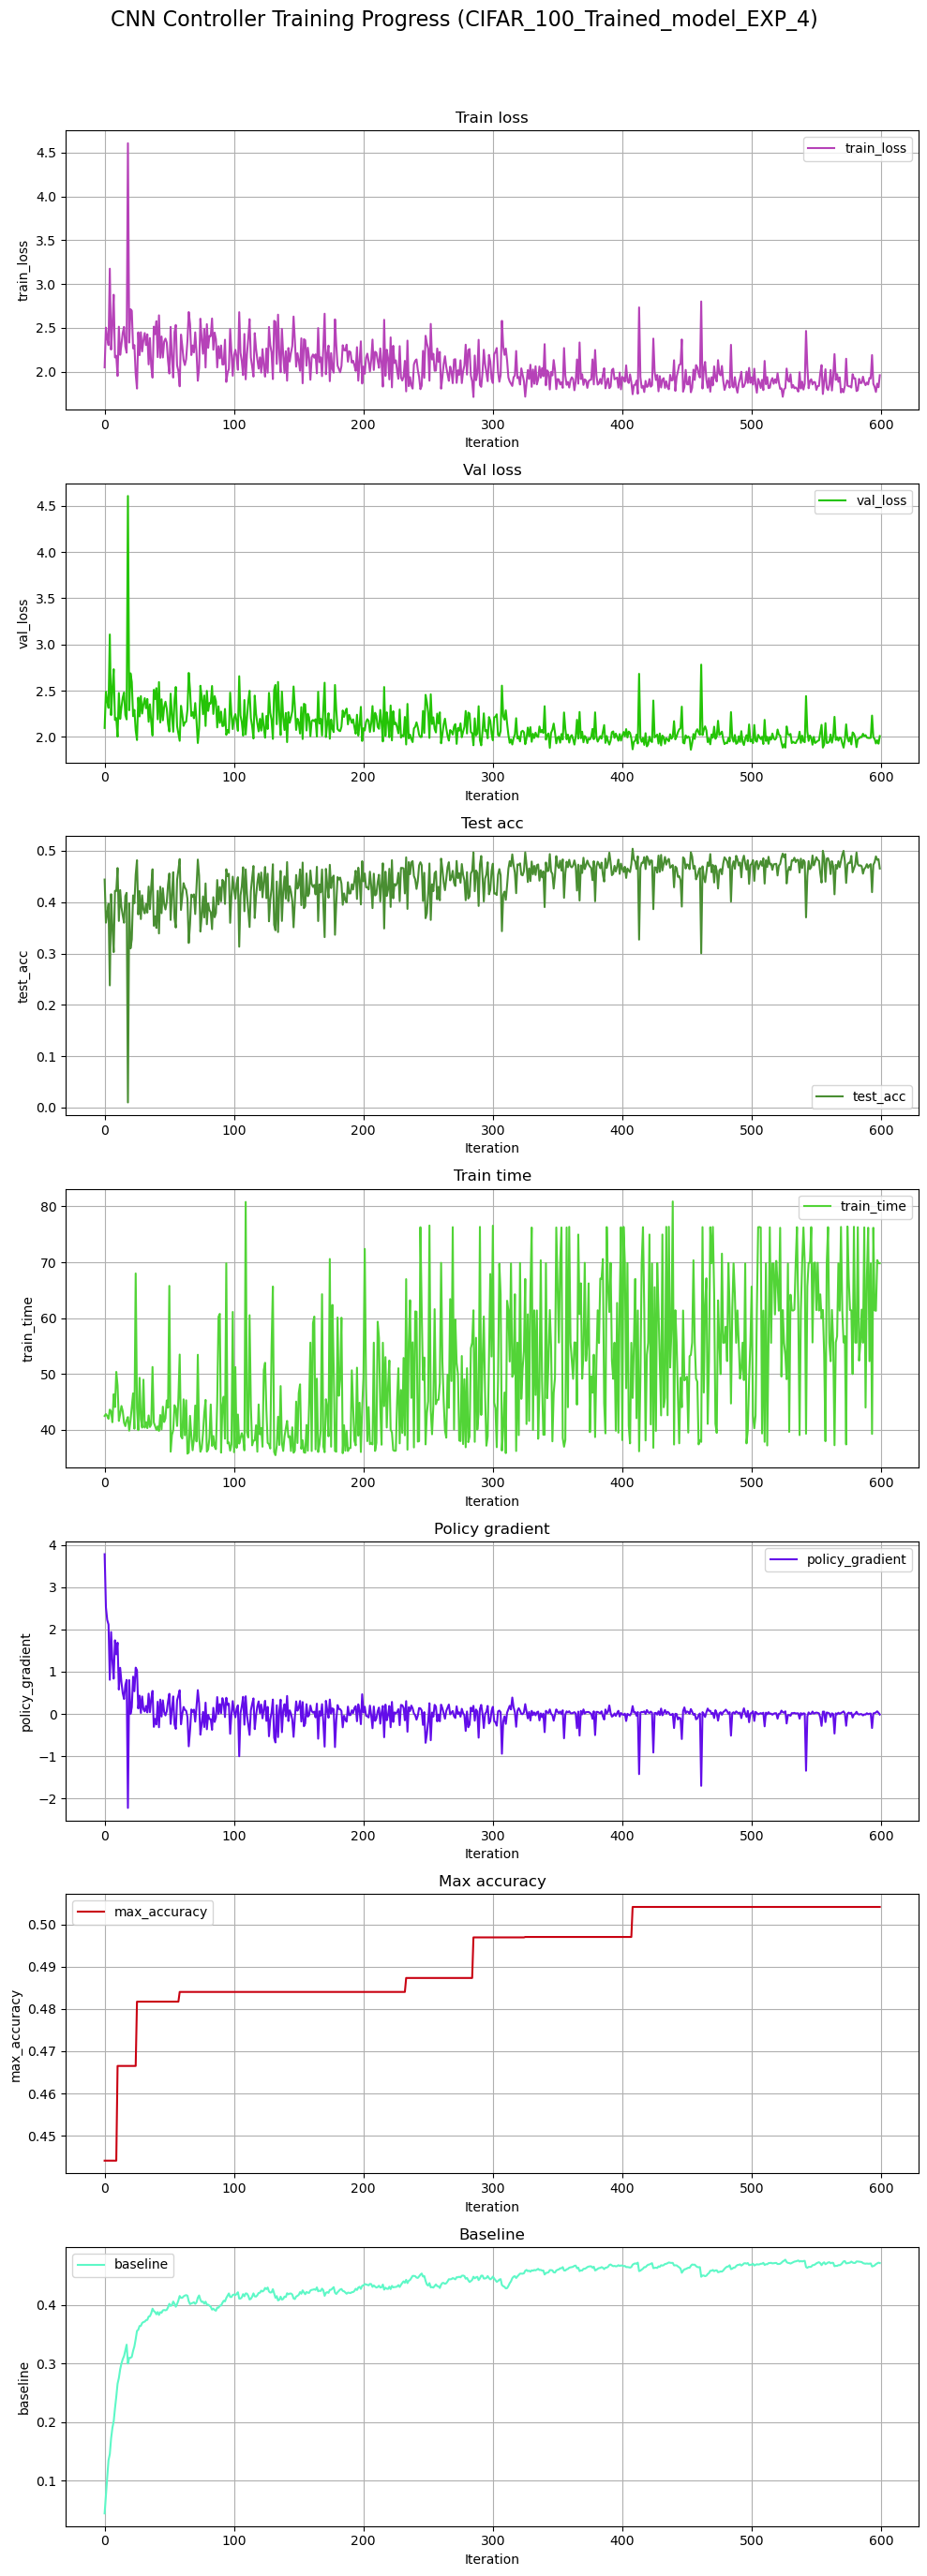

In [36]:
utils.plot_metrics(fresh_controller)

## Load model pre-trained on CIFAR-10